# Análisis Exploratorio de Datos: Titanic

En esta actividad usaremos la base de datos de pasajeros del Titanic para practicar **análisis exploratorio de datos (EDA)**.

El objetivo no es hacer la mayor cantidad posible de gráficos, sino aprender a **usar los datos para responder preguntas**.

## Pregunta de investigación

> **¿Qué características de los pasajeros estaban asociadas con la supervivencia en el Titanic?**


## Librerías de visualización
### Matplotlib

Matplotlib tiene dos métodos para crear una figura, uno directo y otro enfocado a objetos. 
Algunos links de interés:

- Argumentos que reciben matplotlib: https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.plot.html
- Más opciones de gráficos en https://matplotlib.org/2.0.2/gallery.html
- Para una lista de colores disponibles en Matplotlib, https://matplotlib.org/stable/gallery/color/named_colors.html
- Explicación de plt y ax https://towardsdatascience.com/what-are-the-plt-and-ax-in-matplotlib-exactly-d2cf4bf164a9


### Seaborn
Proporciona una interfaz de alto nivel para dibujar gráficos estadísticos atractivos e informativos. A diferencia de Matplotlib, ésta no viene por defecto en Pandas. 
Galería de gráficos: https://seaborn.pydata.org/examples/index.html

Otro link útil para visualizaciones en Python: https://python-graph-gallery.com/


In [32]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

sns.set_style("white")


## Carga de los datos

Cada fila de la base de datos corresponde a **un pasajero**.

Las principales características disponibles son:

- `Survived`: supervivencia, 0 = no, 1 = sí
- `Pclass`: clase del pasajero, 1 = primera, 2 = segunda, 3 = tercera
- `Sex`: sexo
- `Age`: edad
- `SibSp`: número de hermanos/as o cónyuges a bordo
- `Parch`: número de padres o hijos a bordo
- `Ticket`: identificador del pasaje
- `Fare`: tarifa pagada
- `Cabin`: cabina
- `Embarked`: puerto de embarque, C = Cherbourg, Q = Queenstown, S = Southampton


In [33]:
ruta = "/home/gaspar/Escritorio/Universidad/Machine_Learning/"
titanic = pd.read_csv(ruta + "titanic.csv")
titanic.head()


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [34]:
titanic.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


#### **cuáles variables son numéricas y cuáles son categoricas?**



- Variables numericas: PassengerId, Survived, Pclass, Age, SibSp,	Parch, Fare
- Variables categoricas: Name, Sex, Ticket, Cabin, Embarked

# Parte 1: Comprender la muestra

## ¿Quiénes eran los pasajeros del Titanic?

Antes de estudiar la supervivencia, necesitamos comprender a quiénes representan los datos.

Preguntas iniciales:

- ¿Cuántos pasajeros hay?
- ¿Qué características contiene la base de datos?
- ¿Cómo se distribuyen por sexo y clase?
- ¿Qué edades aparecen?
- ¿Cuánto pagaron por sus pasajes?
- ¿Viajaban solos o acompañados?
- ¿Desde qué puerto embarcaron?

Revise la estructura general de la tabla: dimensión, columnas, estadística básica, etc.

- El dataset contiene un total de 891 pasajeros.
- Contiene 12 variables: PassengerId (ID), Survived (supervivencia), Pclass (clase), Name (nombre), Sex (sexo), Age (edad), SibSp (hermanos/cónyuges a bordo), Parch (padres/hijos a bordo), Ticket (número de boleto), Fare (tarifa pagada), Cabin (cabina) y Embarked (puerto de embarque).
- Predominan los hombres con 577, frente a 314 mujeres. La mayoría viajaba en Clase 3 con 491 pasajeros, seguida de la Clase 1 con 216 y la Clase 2 con 184.
- Aparecen edades en un rango continuo desde 0.42 años hasta los 80 años.
- Las tarifas varían desde 0 hasta un máximo de 512.
- La mayoría viajaba sola: 537 pasajeros iban sin familiares a bordo, mientras que 354 pasajeros viajaban acompañados por al menos un familiar.
- La gran mayoría embarcó en Southampton (S) con 644 pasajeros, seguido por Cherbourg (C) con 168 y Queenstown (Q) con 77, contando con solo 2 datos faltantes.

### Ejemplo de gráfico: pasajeros por sexo

Para una característica categórica podemos comenzar contando cuántos pasajeros pertenecen a cada grupo.


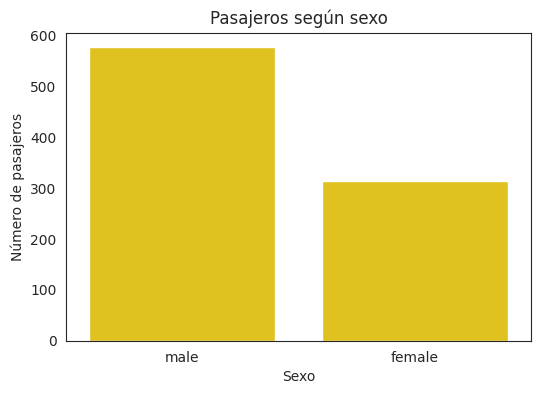

In [35]:
plt.figure(figsize=(6,4))

sns.countplot(data=titanic, x="Sex", color="gold")

plt.xlabel("Sexo")
plt.ylabel("Número de pasajeros")
plt.title("Pasajeros según sexo")

plt.show()


### Ahora usted

**1. Grafique la cantidad de pasajeros según `Pclass`.**

- Qué clase contiene más pasajeros?
- La muestra está balanceada entre las tres clases?


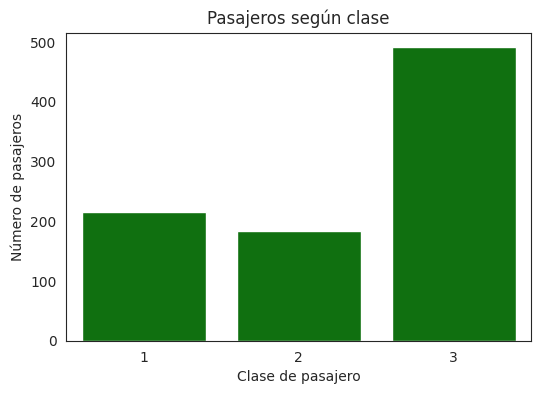

In [36]:
# Escriba aquí su código

plt.figure(figsize=(6,4))

sns.countplot(data=titanic, x="Pclass", color="green")

plt.xlabel("Clase de pasajero")
plt.ylabel("Número de pasajeros")
plt.title("Pasajeros según clase")

plt.show()

La clase que contiene mas pasajeros es la Clase 3, la cual representa a la gran mayoria de personas a bordo, denotando que la muestra esta desbalanceada entre clases.

**2. Explore la distribución de `Age` con un histograma.**

Pruebe, por ejemplo, con 15, 30 y 50 bins.

- ¿Qué edades son más frecuentes?
- ¿La distribución parece simétrica?
- ¿El número de bins cambia su interpretación?


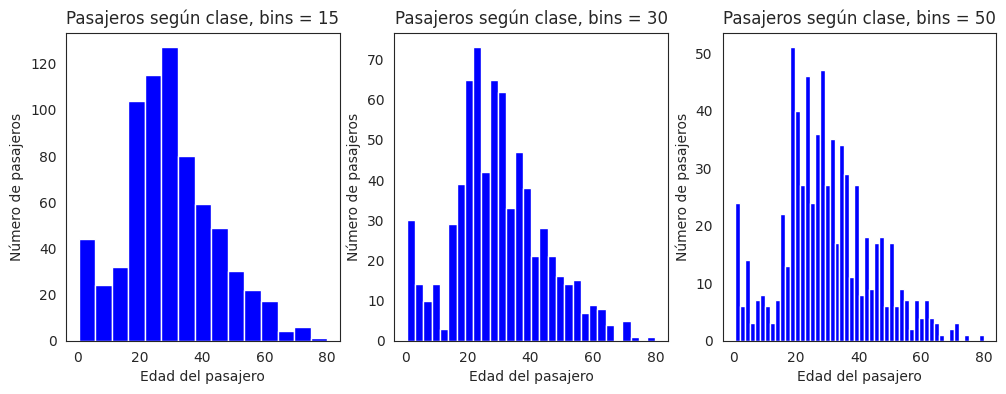

In [37]:
# Escriba aquí su código
# sns.histplot(...)
fig, [ax1, ax2, ax3] = plt.subplots(1, 3, figsize=(12,4))

ax1.hist(data=titanic, x="Age", color="blue", bins=15)
ax1.set_xlabel("Edad del pasajero")
ax1.set_ylabel("Número de pasajeros")
ax1.set_title("Pasajeros según clase, bins = 15")

ax2.hist(data=titanic, x="Age", color="blue", bins=30)
ax2.set_xlabel("Edad del pasajero")
ax2.set_ylabel("Número de pasajeros")
ax2.set_title("Pasajeros según clase, bins = 30")

ax3.hist(data=titanic, x="Age", color="blue", bins=50)
ax3.set_xlabel("Edad del pasajero")
ax3.set_ylabel("Número de pasajeros")
ax3.set_title("Pasajeros según clase, bins = 50")

plt.show()

- Las edades más frecuentes se concentran entre los 20 y 30 años. La distribución no es simétrica debido a la presencia de una cola de adultos mayores hasta 80 años y a un peak secundario en niños.
- Aumentar el número de bins incrementa la resolución del gráfico, permitiendo identificar detalles y peaks locales. En el caso contrario, reducir los bins suaviza la distribución para estudiar la tendencia global y el comportamiento promedio.

**3. Explore la distribución de `Fare`.**

Puede usar un histograma o un boxplot.

- ¿La distribución es simétrica?
- ¿Existen tarifas muy superiores al resto?
- ¿Qué podría significar esto?


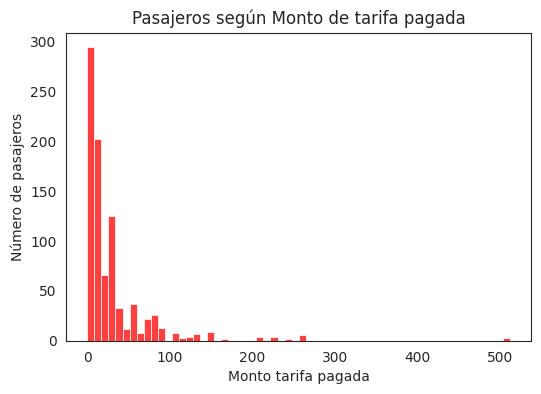

In [38]:
# Escriba aquí su código

plt.figure(figsize=(6,4))

sns.histplot(data=titanic, x="Fare", color="red")

plt.xlabel("Monto tarifa pagada")
plt.ylabel("Número de pasajeros")
plt.title("Pasajeros según Monto de tarifa pagada")

plt.show()

- La distribución presenta una mayor concentración en valores muy bajos de la tarifa (debajo de 20) y una caída drástica a medida que el monto aumenta, encontrandose con que el monto maximo, se encuentra sobre 500, demostrando que hay tarifas muy superiores a la media.
- Dado que la mayoría de los pasajeros pertenecían a la Clase 3 (donde las tarifas eran las más accesibles), el grueso de la distribución se agrupa en el rango bajo de precios. Por el contrario, los valores más altos corresponden exclusivamente a Clase 1, evidenciando el marcado contraste entre el pasaje masivo de clase baja y una minoría de ingresos elevados.

# Parte 2: Calidad de los datos

## ¿Qué información falta y por qué podría importar?

Antes de interpretar cualquier patrón debemos revisar la calidad de los datos.

Nos interesa detectar:

- valores faltantes
- características con mucha información incompleta
- valores extremos o sospechosos
- decisiones de limpieza que puedan cambiar nuestras conclusiones


In [39]:
datos_faltantes = titanic.isnull().sum()
datos_faltantes


PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

### Ejemplo de gráfico: valores faltantes

Podemos visualizar cuántos datos faltan en cada característica.


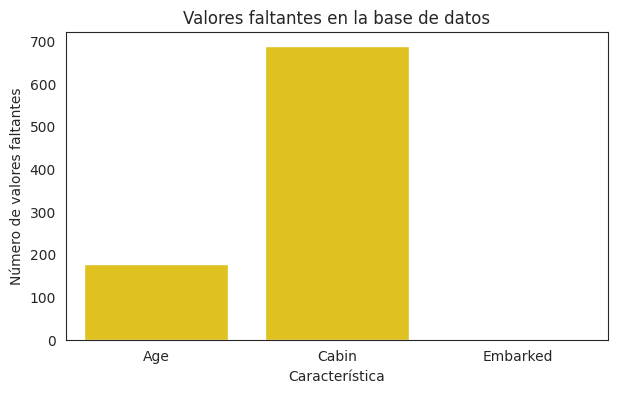

In [40]:
faltantes = datos_faltantes[datos_faltantes > 0]

plt.figure(figsize=(7,4))

sns.barplot(x=faltantes.index, y=faltantes.values, color='gold')

plt.xlabel("Característica")
plt.ylabel("Número de valores faltantes")
plt.title("Valores faltantes en la base de datos")

plt.show()


### Ahora usted

Observe especialmente `Age`, `Cabin` y `Embarked`.

**1. Compare la media y la mediana de `Age`.**

- Son similares?
- Es la media una buena representación de una edad típica?


In [41]:
# Escriba aquí su código
media_age = np.nanmean(titanic["Age"])
mediana_age = np.nanmedian(titanic["Age"])

print(f"Media de la edad: {media_age:.4}")
print(f"Mediana de la edad: {mediana_age:.4}")

Media de la edad: 29.7
Mediana de la edad: 28.0


Los valores son similares, y debido a esto la media es una buena representación como medida de tendencia central, ya que no existen sesgos tan severos como en el caso de las tarifas. Sin embargo, no es suficiente por sí sola para describir a la población "típica".

**2. La edad tiene datos faltantes.**

- Le parece razonable reemplazar todas las edades faltantes por la media?
- Qué problema podría producir esa decisión en la distribución de edades?
- Qué otra estrategia consideraría?


- No es razonable, ya que al imputar un valor único a un porcentaje alto de datos se asume que todos esos pasajeros tenían la misma edad, ignorando la variabilidad real de la muestra.
- Generaría un peak artificial y desproporcionado en el valor de la media, alterando la forma de la distribución y reduciendo artificialmente la varianza y la desviación estándar.
- Consideraría imputar la edad mediante la mediana según grupos específicos, por ejemplo calculando la mediana de edad agrupada por Pclass y Title.

**3. `Cabin` tiene una gran cantidad de valores faltantes.**

- Intentaría rellenarlos?
- Eliminaría la característica?
- Podría el hecho de conocer o no la cabina contener información por sí mismo?

No hay una única respuesta correcta: justifique su decisión.


- No intentaría rellenarlos, debido a que la enorme cantidad de datos faltantes haría inapropiada e imprecisa cualquier imputación.
- No completamente. Lo que haria seria crear un indicador binario (0 o 1) que refleje la presencia o ausencia de registro.
- Si porque la ausencia del dato no es realmente aleatoria, los pasajeros de Clase 1 tienen un registro mucho mayor de Cabin que los de Clase 3, convirtiendo un dato faltante en un indicador indirecto de mayor estatus socioeconómico.

**4. `Embarked` tiene pocos datos faltantes.**

- Qué estrategia simple usaría en este caso?
- Por qué el tratamiento puede ser distinto al de `Cabin`?


- Reemplazar los dos únicos valores faltantes por la moda.
- Porque la proporción de datos faltantes es insignificante, por lo que imputar la moda no distorsiona en absoluto la distribución global ni introduce sesgos relevantes.

# Parte 3: Explorar relaciones entre características

## ¿Cómo se relacionan las características de los pasajeros?

Después de estudiar las características individualmente, podemos comenzar a buscar estructura en los datos.

Preguntas posibles:

- La tarifa pagada está relacionada con la clase?
- Las edades son similares en todas las clases?
- Quiénes viajaban acompañados?
- Hay características que contienen información parcialmente similar?



### Ejemplo de gráfico: tarifa según clase

Un boxplot permite comparar la distribución de una característica numérica entre distintos grupos.


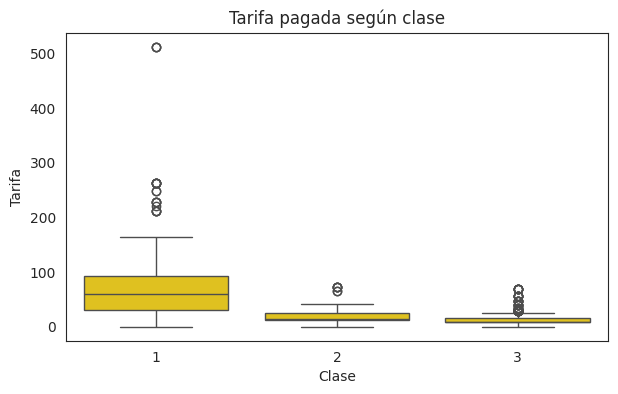

In [42]:
plt.figure(figsize=(7,4))

sns.boxplot(data=titanic, x="Pclass", y="Fare", color='gold')

plt.xlabel("Clase")
plt.ylabel("Tarifa")
plt.title("Tarifa pagada según clase")

plt.show()

### Preguntas

- La tarifa parece estar relacionada con la clase?
- Hay dispersión dentro de cada clase?
- Existen valores extremos?
- Diría que `Fare` y `Pclass` contienen exactamente la misma información?
    

- Existe una relación directa, la mediana y el rango de la tarifa aumentan considerablemente a medida que la clase es de mayor estatus (de Clase 3 a Clase 1).
- Hay dispersión en las tres clases, pero es drásticamente mayor en la Clase 1, mientras que en la Clase 2 y 3 las tarifas están mucho más concentradas en rangos estrechos.
- Se observan valores extremos en las tres clases, siendo especialmente notorios en la Clase 1, donde destacan tarifas que superan los 200 y hasta los 500.
- Aunque están altamente relacionadas no son idénticas, Pclass es una categoría discreta fija, mientras que Fare es una variable continua que aporta variabilidad adicional.

### Ahora usted

**1. Compare la distribución de edad entre las tres clases.**

Use un gráfico que permita comparar las distribuciones.

- Los pasajeros tienen edades similares en todas las clases?
- Qué diferencias observa?


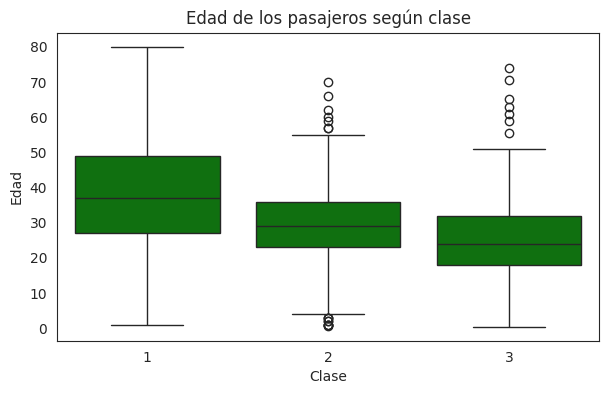

In [43]:
# Escriba aquí su código
# sns.boxplot(...)
plt.figure(figsize=(7,4))

sns.boxplot(data=titanic, x="Pclass", y="Age", color='green')

plt.xlabel("Clase")
plt.ylabel("Edad")
plt.title("Edad de los pasajeros según clase")

plt.show()

- Los pasajeros presentan diferentes distribuciones de edades a cada clase. 
- La Clase 1 concentra a la población más adulta y longeva, la Clase 2 presenta un perfil predominantemente joven-adulto, y la Clase 3 es drásticamente la más joven contando con la mayor concentración de niños.

**2. Las características `SibSp` y `Parch` contienen información sobre familiares a bordo.**

Construya una nueva característica llamada `Familia`, que represente el número total de personas del grupo familiar incluyendo al propio pasajero:

\[
Familia = SibSp + Parch + 1
\]


In [44]:
# Complete el código

titanic["Familia"] = titanic["SibSp"] + titanic["Parch"]

**3. Explore la nueva característica `Familia`.**

- La mayoría de los pasajeros viajaba sola o acompañada?
- Hay grupos familiares muy grandes?
- Cambiaría su interpretación si solo mirara `SibSp` o `Parch` por separado?


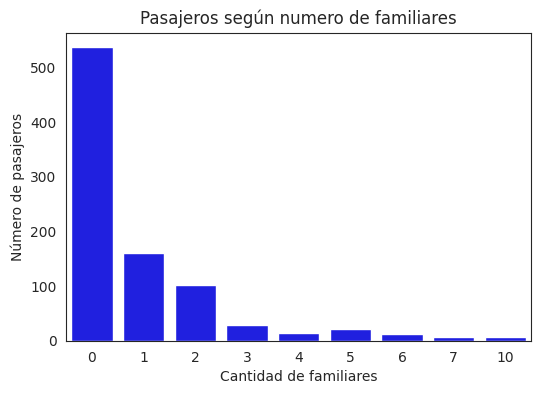

In [45]:
# Escriba aquí su código
plt.figure(figsize=(6,4))

sns.countplot(data=titanic, x="Familia", color="blue")

plt.xlabel("Cantidad de familiares")
plt.ylabel("Número de pasajeros")
plt.title("Pasajeros según numero de familiares")

plt.show()

- La gran mayoria de los pasajeros viajaban solos. 
- Pese a esto, un pequeño porcentaje presentaba un amplio grupo familiar de hasta 10 integrantes. 
- Mirar SibSp o Parch por separado podria introducir sesgos de subestimación en la cantidad de familiares que un pasajero puede tener

# Parte 4: Investigar la supervivencia

## ¿Qué características estaban asociadas con la supervivencia?

Ahora incorporaremos `Survived`, la variable que queremos comprender.

Investigaremos si la supervivencia está asociada con características como:

- sexo
- clase
- edad
- tamaño del grupo familiar


### Ejemplo de gráfico: supervivencia según sexo

Como `Survived` toma valores 0 y 1, su promedio dentro de un grupo corresponde a la **fracción de pasajeros que sobrevivió**.

`seaborn.barplot` calcula por defecto la media de la variable del eje vertical.


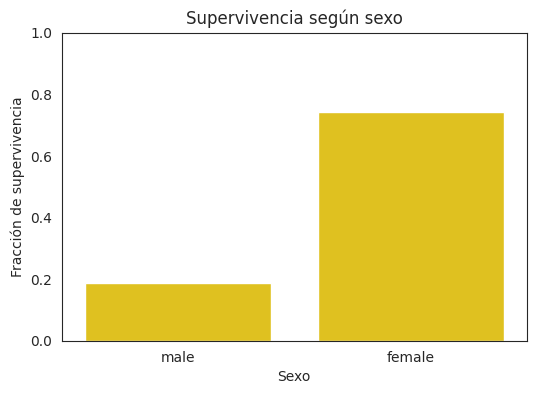

In [46]:
plt.figure(figsize=(6,4))

sns.barplot(data=titanic, x="Sex", y="Survived", errorbar=None, color='gold')

plt.xlabel("Sexo")
plt.ylabel("Fracción de supervivencia")
plt.title("Supervivencia según sexo")
plt.ylim(0,1)

plt.show()

### Preguntas

- La fracción de supervivencia es similar para hombres y mujeres?
- Podemos concluir a partir de este gráfico por qué existe la diferencia?


- La fracción de supervivencia no es similar entre hombres y mujeres. Las mujeres presentan una amplia mayor fracción.
- Solo con la información de este grafico no se puede concluir la razón de la diferencia, necesitamos información adicional para ello.

### Ahora usted

**1. Explore la supervivencia según `Pclass`.**

- Hay diferencias entre las tres clases?
- Existe una tendencia?


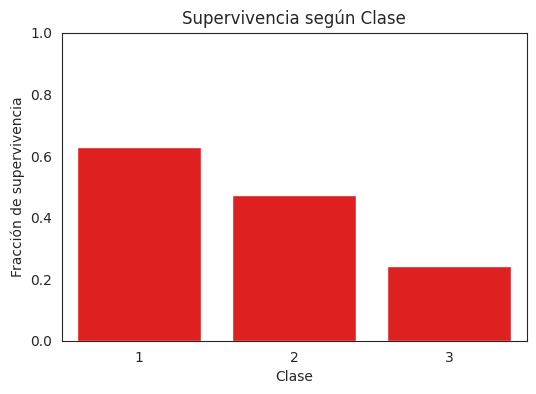

In [47]:
# Escriba aquí su código
plt.figure(figsize=(6,4))

sns.barplot(data=titanic, x="Pclass", y="Survived", errorbar=None, color='red')

plt.xlabel("Clase")
plt.ylabel("Fracción de supervivencia")
plt.title("Supervivencia según Clase")
plt.ylim(0,1)

plt.show()

- Existe una diferencia entre el porcentaje de supervivencia por clase, particularmente se aprecia una tendencia descendente con el número de Clase. A mayor el número, menor porcentaje de personas sobrevivieron. Al igual que con el grafico anterior, no se puede determinar la razon de esta tendencia.

**2. Explore la supervivencia según edad.**

Puede comparar las distribuciones de edad de quienes sobrevivieron y quienes no sobrevivieron.

- La edad parece estar asociada con supervivencia?
- Hay algún grupo de edad que llame particularmente su atención?


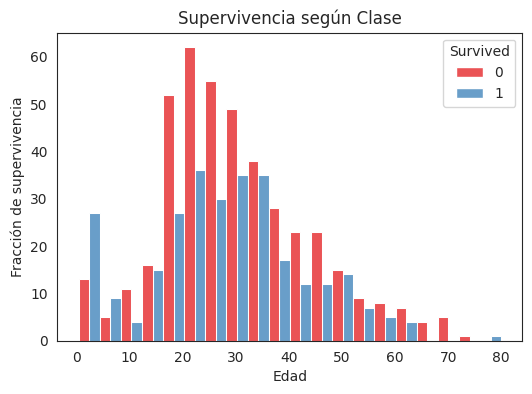

In [48]:
# Escriba aquí su código
plt.figure(figsize=(6,4))

sns.histplot(data=titanic, x="Age", hue="Survived", multiple="dodge", palette="Set1")

plt.xlabel("Edad")
plt.ylabel("Fracción de supervivencia")
plt.title("Supervivencia según Clase")
#plt.ylim(0,1)

plt.show()

- De acuerdo a este grafico se puede notar que existe una relación entre la edad y la supervivencia. Siendo esto evidente con el grupo que mas llama particularmente la atención, el rango de edad 20-30 años, quienes son los presentaron una mayor fraccion de supervivencia que el resto de personas.

**3. Explore la supervivencia según `Familia`.**

- Viajar solo parece favorable o desfavorable?
- La relación parece simple?
- Qué ocurre con los grupos familiares grandes?


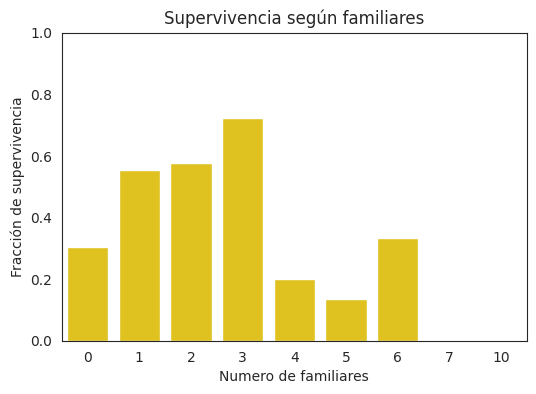

In [49]:
# Escriba aquí su código
plt.figure(figsize=(6,4))

sns.barplot(data=titanic, x="Familia", y="Survived", errorbar=None, color='gold')

plt.xlabel("Numero de familiares")
plt.ylabel("Fracción de supervivencia")
plt.title("Supervivencia según familiares")
plt.ylim(0,1)

plt.show()

- Las mayores fracciones de superviviencia ocurrieron con pasajeros que tenian pocos familiares a bordo.
- Sin embargo, la relación entre la supervivencia y el numero de familiares no es tan simple, ya que no se aprecia una tendencia clara en el grafico. 
- La unica excepcion a esto es para pasajeros con un numero muy grande familiares (mayor o igual a 7). En este caso la superviviencia es nula.

# Parte 5: Agregar contexto

## ¿Cambia una relación cuando consideramos otra característica?

Una relación global puede esconder comportamientos diferentes dentro de la muestra.

Ya estudiamos por separado:

- `Pclass` y supervivencia
- `Sex` y supervivencia

Ahora podemos preguntar:
 **¿La relación entre clase y supervivencia es igual para hombres y mujeres?**

Esta es una forma sencilla de análisis multivariado: consideramos varias características al mismo tiempo.


### Ejemplo de gráfico: clase, sexo y supervivencia


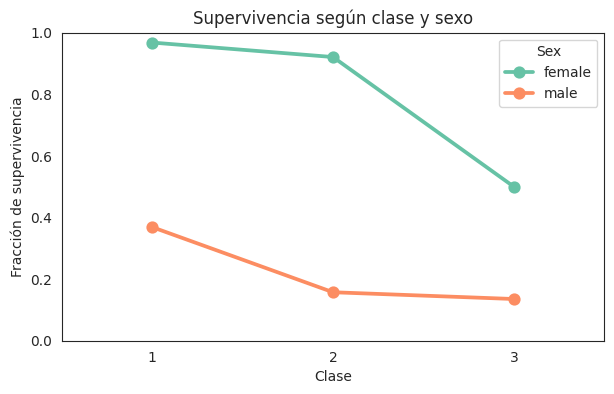

In [50]:
plt.figure(figsize=(7,4))

sns.pointplot(data=titanic,
              x="Pclass",
              y="Survived",
              hue="Sex",
              palette="Set2",
              errorbar=None)

plt.xlabel("Clase")
plt.ylabel("Fracción de supervivencia")
plt.title("Supervivencia según clase y sexo")
plt.ylim(0,1)

plt.show()


### Preguntas sobre el ejemplo

- La relación entre clase y supervivencia es igual para hombres y mujeres?
- Qué información se perdía cuando mirábamos solamente `Pclass`?
- Qué información se perdía cuando mirábamos solamente `Sex`?
- Hay algún grupo particularmente favorecido o desfavorecido?



- La relación clase-supervivencia no es igual para hombres y mujeres. 
- Este grafico revela que la fracción de supervivencia era diferente entre clases, a diferencia de cuando solo mirabamos Pclass, ahí esta información se perdia.
- De forma similar, al mirar solamente Sex se estaba pasando por alto que en cada clase la fracción de supervivencia de hombres y mujeres era diferente.
- Tanto para hombres como mujeres, existe una tendencia a la disminución de la fracción de supervivencia a medida que aumenta el número de Clase. Esto muestra que las personas de Clase 1 fueron las mas favorecidades en terminos de superviviencia a diferencia de las demás, como la Clase 3 que es la mas desfavorecida

### Ahora usted

**1. Cree una característica `Persona` con tres categorías:**

- `mujer`
- `hombre`
- `niño/a`

Considere como niño/a a un pasajero menor de 16 años.


In [51]:
def clasificar_persona(fila):
    if fila["Age"] < 16:
        return "niño"
    elif fila["Sex"] == "male":
        return "hombre"
    else:
        return "mujer"

titanic["Persona"] = titanic.apply(clasificar_persona, axis=1)

# Revise el resultado
titanic["Persona"].value_counts()


Persona
hombre    537
mujer     271
niño       83
Name: count, dtype: int64

**2. Explore la supervivencia según `Persona` y `Pclass`.**

- Los niños presentan el mismo patrón que los adultos?
- La clase sigue siendo importante dentro de cada grupo?
- Qué combinación de características parece asociarse con la mayor supervivencia?


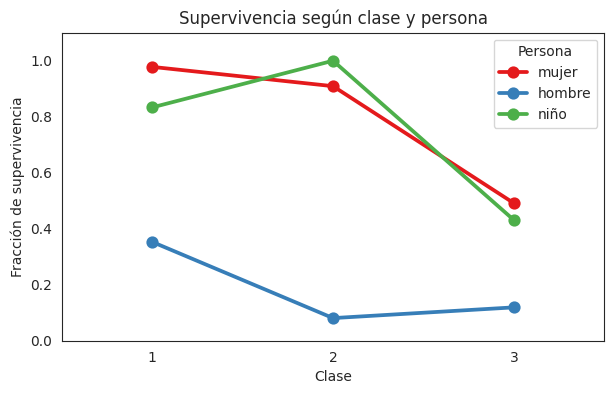

In [52]:
# Escriba aquí su código
plt.figure(figsize=(7,4))

sns.pointplot(data=titanic,
              x="Pclass",
              y="Survived",
              hue="Persona",
              palette="Set1",
              errorbar=None)

plt.xlabel("Clase")
plt.ylabel("Fracción de supervivencia")
plt.title("Supervivencia según clase y persona")
plt.ylim(0,1.1)

plt.show()

**3. Elija una relación adicional para explorar incorporando una tercera característica.**

Algunas ideas:

- edad + sexo + supervivencia;
- tamaño de familia + clase + supervivencia;
- puerto de embarque + clase + supervivencia.

No necesita crear una figura complicada. El objetivo es responder una pregunta concreta.

**Escriba primero la pregunta que quiere investigar y luego construya el gráfico.**


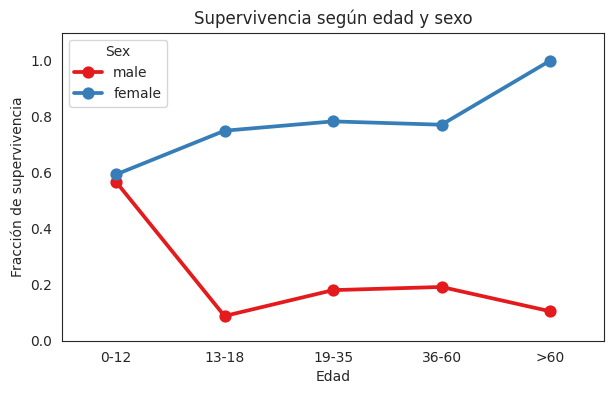

In [53]:
# Pregunta: ¿Existe una relación entre edad y supervivencia de acuerdo al sexo de cada persona?

# Código:

titanic["Rango_Edad"] = pd.cut(
    titanic["Age"],
    bins=[0, 12, 18, 35, 60, 80],
    labels=["0-12", "13-18", "19-35", "36-60", ">60"],
)

plt.figure(figsize=(7,4))

sns.pointplot(data=titanic,
              x="Rango_Edad",
              y="Survived",
              hue="Sex",
              palette="Set1",
              errorbar=None)

plt.xlabel("Edad")
plt.ylabel("Fracción de supervivencia")
plt.title("Supervivencia según edad y sexo")
plt.ylim(0,1.1)

plt.show()


# Parte 6: Conclusión

## ¿Qué podemos concluir?

El EDA no termina cuando encontramos diferencias entre grupos.

Queremos distinguir entre:

### Observación
Algo que vemos directamente en los datos.

### Interpretación
Cómo describimos ese patrón.

### Hipótesis
Una explicación posible que debería ser evaluada con más información.

Por ejemplo:

> **Observación:** las mujeres presentan una mayor fracción de supervivencia que los hombres.

- **Podemos concluir, solo a partir de esta base de datos, que durante la evacuación se dio prioridad a mujeres y niños?**
- **Qué información adicional necesitaríamos para evaluar esa hipótesis?**
- **Qué otras explicaciones podrían producir el mismo patrón de supervivencia?**

- Pese a que los datos apoyan la hipotesis dada la correlacion entre estos, esto no implica necesariamente que sea la causa, por lo que se requiere de mayor información para asegurarla.
- Entre muchas otras cosas, información sobre como se cargaron los botes salvavidas. Quienes los abordaron, que tan rapido fue, si quedaron asientos vacios, etc.
- Un par de explicaciones podria ser que las personas de Clase 3, compuesta mayoritariamente por hombres, al estar ubicadas mas lejos de los botes salvavidas no pudieron acceder con suficiente rapidez a escapar. Otra explicacion podria ser factores ambientales y fisiologicos, que marcaban la resistencia a las bajas temperaturas.

## Síntesis del análisis

Revise todas las figuras construidas y responda:

### 1. Quiénes eran los pasajeros del Titanic?

Describa brevemente la muestra considerando, al menos:

- sexo
- clase
- edad
- tamaño de familia.


### 2. Qué características estaban asociadas con la supervivencia?

Considere:

- sexo
- clase
- edad
- viajar solo o acompañado.



### 3. Qué relaciones cambiaron al considerar varias características al mismo tiempo?

Use como ejemplo al menos uno de los análisis multivariados realizados.


### 4. Encontró características que contienen información relacionada?

Explique al menos un caso.


### 5. Qué resultado le pareció más inesperado?

Proponga una posible explicación, dejando claro qué parte corresponde a una observación y qué parte corresponde a una hipótesis.


1. Predominaban los hombres, siendo la mayoria frente a las mujeres. La mayoría viajaba en Clase 3, seguido de Clase 1 y finalmente Clase 2. La edad promedio era de 29.7 años (con una mediana de 28 años), con un rango que abarcaba desde recien nacidos hasta los 80 años. La mayoria de los pasajeros viajaban solos. Y entre quienes viajaban acompañados, el tamaño familiar más común era de 2 a 4 integrantes (sumando hermanos/conyuges y padres/hijos).

2. Fue el factor determinante más fuerte, las mujeres tuvieron una tasa de supervivencia mucho mayor que la de los hombres. A mayor clase socioeconómica, mayor supervivencia. Adicionalmente, ser niño (< 16 años) incrementó significativamente la probabilidad de sobrevivir frente a los adultos. Finalmente quienes viajaban acompañados con hasta 3 personas tuvieron mayor supervivencia que quienes viajaban solos y aun mas de quienes tenian mas acompañantes.

3. Por ejemplo, al analizar la superviviencia cruzando sexo y clase simultáneamente se evidenció que la supervivencia de las mujeres en Clase 1 y 2 fue casi total, pero cayó considerablemente para las mujeres en Clase 3. Esto demuestra que durante la evacuación no se dio prioridad a las personas exclusivamente por el sexo, sino que por la clase tambien. 

4. Las columnas de clase y tarifa otorgan información redudante: el costo del boleto está condicionado por la clase misma. Lo mismo ocurre entre "SibSp + Parch" y "Familia", ambas columnas miden la estructura familiar de cada pasajero, pudiendo determinar el tamaño del grupo o si viajaba solo.

5. Observacion: Los hombres de Clase 1 tuvieron una tasa de supervivencia considerablemente mas baja que las mujeres de su misma clase, considerando que pertenecían al grupo con mayor acceso físico y privilegios a bordo, siendo superados incluso por las mujeres de Clase 3.
Hipotesis: Como se planteó anteriormente, el protocolo de evacuación de "mujeres y niños primero" ejercieron una presión de género tan estricta que prevaleció sobre el privilegio socioeconómico, relegando al hombre adulto independientemente de su estatus o ubicación en el barco. 

# Conclusión final

## ¿Cuál es el perfil del pasajero típico que sobrevivió?

A partir de **sus propios resultados**, escriba una conclusión breve que caracterice al pasajero con mayor probabilidad de haber sobrevivido en esta muestra.

Considere, cuando corresponda:

- sexo
- edad
- clase
- tamaño del grupo familiar
- otras características que hayan resultado relevantes

Su respuesta debe estar respaldada por las figuras que construyó.


### Escriba aquí su conclusión

**El pasajero típico que sobrevivió...**

*(Complete con un párrafo breve basado en su análisis.)*


El pasajero tipico que sobrevivió corresponde a una mujer de Clase 1 o 2, de corta edad y que viajaba acompañada por un grupo familiar pequeño (2 a 4 personas). Este perfil se respalda directamente en los datos: las mujeres de clases altas alcanzaron una supervivencia superior al 92%, los menores de 16 años tuvieron prioridad de evacuación transversal respecto a los adultos de su mismo sexo, y viajar en un grupo familiar reducido incrementó la tasa de supervivencia frente a pasajeros solitarios, evitando a su vez las dificultades logísticas de las familias numerosas.